Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import sys
import sklearn

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

**Implementation Detail**

In [ ]:
print("Python version:", sys.version)
print("Scikit-learn version:", sklearn.__version__)

RANDOM_STATE = 42
print("Global random seed:", RANDOM_STATE)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Scikit-learn version: 1.6.1
Global random seed: 42


**Load Dataset**

In [ ]:
df = pd.read_csv("data/student_data.csv")

print(df.head())
print(df.info())
print("Original dataset shape:", df.shape)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (to

In [ ]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


Checking Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

### Remove Duplicate

In [ ]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (395, 33)


Check Data Type

In [ ]:
print("\nData types:\n", df.dtypes)


Data types:
 school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


### Detect Outliers

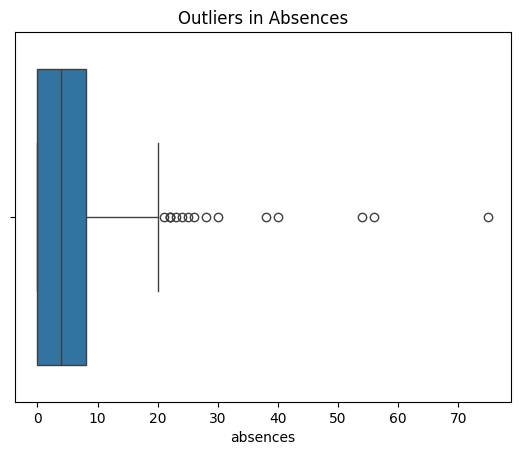

In [ ]:
plt.figure()
sns.boxplot(x=df['absences'])
plt.title("Outliers in Absences")
plt.show()

Data Processing
Encoded Categorial Variables


In [ ]:
le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])
print("After encoding shape:", df_encoded.shape)

After encoding shape: (395, 33)


Create Classification target (target variable creation)

In [ ]:
df_encoded['G3_pass'] = df_encoded['G3'].apply(lambda x: 1 if x >= 10 else 0)

In [ ]:
print(df_encoded['G3_pass'])


0      0
1      0
2      1
3      1
4      1
      ..
390    0
391    1
392    0
393    1
394    0
Name: G3_pass, Length: 395, dtype: int64


Feature/Target Split

In [ ]:
X = df_encoded.drop(['G3', 'G3_pass'], axis=1)
y = df_encoded['G3_pass']

In [ ]:
print(X,y)

     school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0         0    0   18        1        0        0     4     4     0     4  ...   
1         0    0   17        1        0        1     1     1     0     2  ...   
2         0    0   15        1        1        1     1     1     0     2  ...   
3         0    0   15        1        0        1     4     2     1     3  ...   
4         0    0   16        1        0        1     3     3     2     2  ...   
..      ...  ...  ...      ...      ...      ...   ...   ...   ...   ...  ...   
390       1    1   20        1        1        0     2     2     3     3  ...   
391       1    1   17        1        1        1     3     1     3     3  ...   
392       1    1   21        0        0        1     1     1     2     2  ...   
393       1    1   18        0        1        1     3     2     3     2  ...   
394       1    1   19        1        1        1     1     1     2     0  ...   

     romantic  famrel  free

Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,stratify=y
)


In [ ]:
print(X_train)
print("\nTraining samples:", len(X_train))

print("Testing samples:", len(X_test))


     school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
140       0    1   15        1        0        1     4     3     4     3  ...   
245       0    1   16        1        0        1     2     1     2     2  ...   
131       0    0   15        1        0        1     1     1     0     2  ...   
153       0    1   19        1        0        1     3     2     3     0  ...   
386       1    0   18        0        0        1     4     4     4     0  ...   
..      ...  ...  ...      ...      ...      ...   ...   ...   ...   ...  ...   
29        0    1   16        1        0        1     4     4     4     4  ...   
181       0    1   16        1        0        1     3     3     3     2  ...   
252       0    1   18        1        0        1     2     1     3     3  ...   
300       0    0   18        1        1        0     4     4     1     2  ...   
350       1    1   19        0        0        1     1     1     2     3  ...   

     romantic  famrel  free

Class Distribution

In [ ]:
print("\nFull Dataset Distribution:")
print(y.value_counts(normalize=True))

print("\nTraining Set Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Set Distribution:")
print(y_test.value_counts(normalize=True))


Full Dataset Distribution:
G3_pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64

Training Set Distribution:
G3_pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64

Testing Set Distribution:
G3_pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64


## Feature Selection


Correlation Analysis

In [ ]:
corr = df_encoded.corr()

print("\nCorrelation with G3:\n")
print(corr['G3'].sort_values(ascending=False))


Correlation with G3:

G3            1.000000
G2            0.904868
G1            0.801468
G3_pass       0.770042
Medu          0.217147
higher        0.182465
Fedu          0.152457
reason        0.121994
address       0.105756
sex           0.103456
Mjob          0.102082
paid          0.101996
internet      0.098483
studytime     0.097820
famsize       0.081407
nursery       0.051568
famrel        0.051363
Fjob          0.042286
absences      0.034247
activities    0.016100
freetime      0.011307
famsup       -0.039157
school       -0.045017
Walc         -0.051939
Dalc         -0.054660
Pstatus      -0.058009
health       -0.061335
guardian     -0.070109
schoolsup    -0.082788
traveltime   -0.117142
romantic     -0.129970
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


Correaction Heatmap Visulization

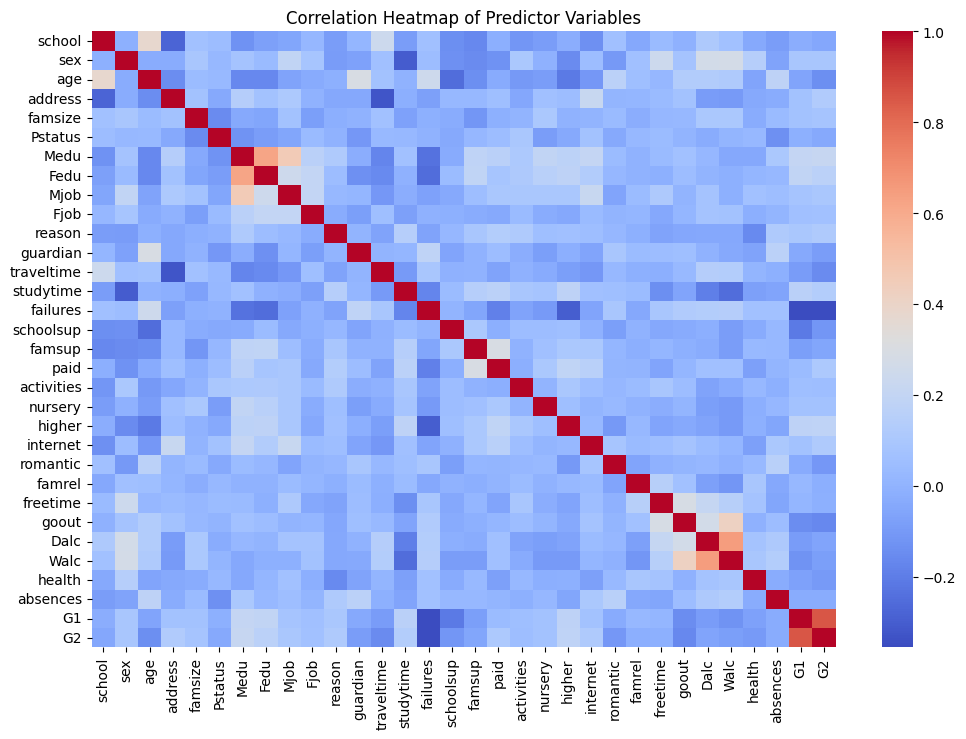

In [ ]:

corr_features = df_encoded.drop(
    ['G3', 'G3_pass'],
    axis=1
)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_features.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap of Predictor Variables")

plt.show()

Chip-Squared Test

In [ ]:
from sklearn.feature_selection import chi2

chi_scores, p_values = chi2(X, y)

chi_results = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': chi_scores,
    'p-value': p_values
}).sort_values(by='Chi2 Score', ascending=False)

print("\nChi-Square Results:\n")
print(chi_results.head(10))


Chi-Square Results:

      Feature  Chi2 Score       p-value
31         G2  273.800569  1.685050e-61
30         G1  175.953380  3.706946e-40
14   failures   74.370431  6.475163e-18
29   absences   37.612827  8.627529e-10
25      goout    5.283173  2.153248e-02
10     reason    4.516610  3.356727e-02
15  schoolsup    3.430391  6.400696e-02
22   romantic    2.512293  1.129615e-01
6        Medu    2.286991  1.304626e-01
7        Fedu    2.160517  1.415970e-01


Chip-Square Feature Score Visulization

Text(0, 0.5, 'Features')

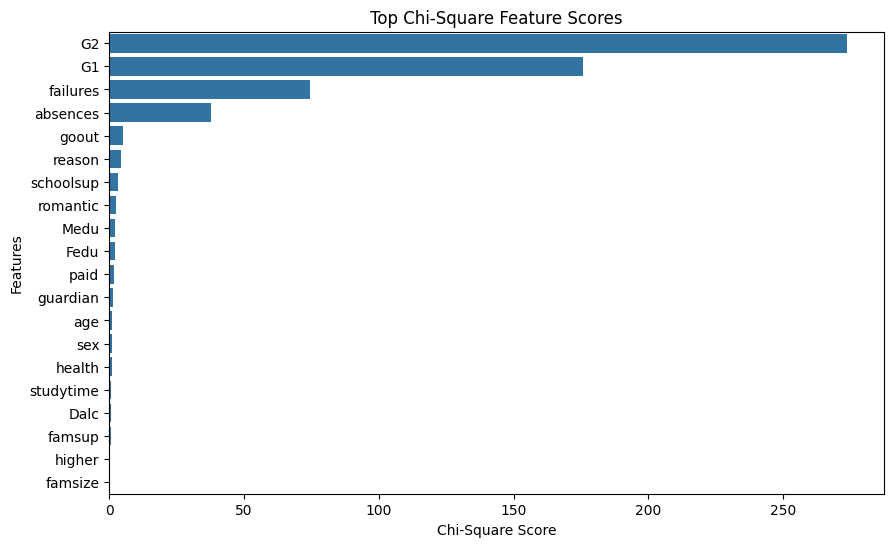

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Chi2 Score',
    y='Feature',
    data=chi_results.head(20)
)

plt.title("Top Chi-Square Feature Scores")

plt.xlabel("Chi-Square Score")

plt.ylabel("Features")


Random Forest Feature Importance

In [ ]:
rf_temp = RandomForestClassifier(random_state=RANDOM_STATE)
rf_temp.fit(X_train, y_train)

importance = pd.Series(rf_temp.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nTop 5 Features:\n")
print(importance.head(5))



Top 5 Features:

G2          0.402700
G1          0.190286
failures    0.046134
absences    0.039691
goout       0.025438
dtype: float64


Random Forest Feature Importance Visualization

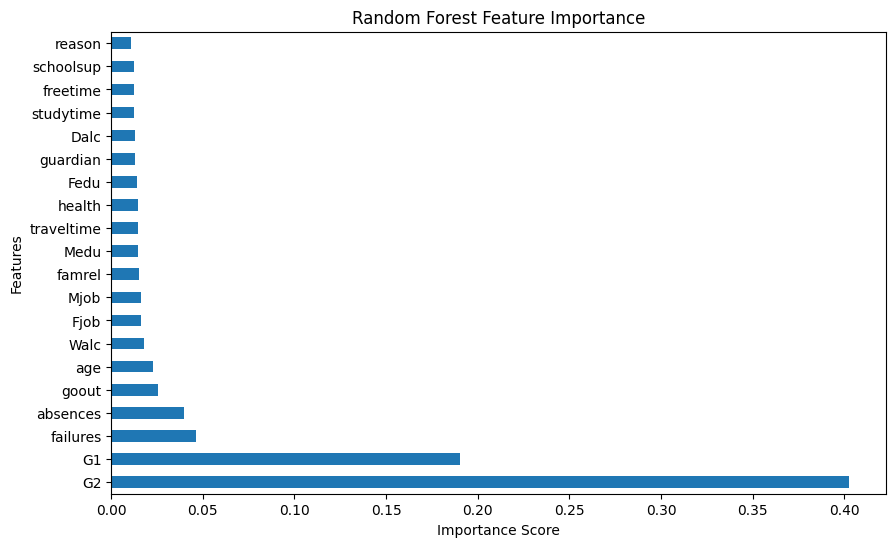

In [ ]:
plt.figure(figsize=(10,6))

importance.head(20).plot(kind='barh')

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()


Remove Unnecessary Columns

In [ ]:
low_features = importance[importance < 0.01].index

print("Removed features (importance < 0.01):", list(low_features))

# Remove them
X_reduced = X.drop(columns=low_features)

print("Final dataset shape:", X_reduced.shape)

Removed features (importance < 0.01): ['nursery', 'activities', 'romantic', 'famsize', 'paid', 'internet', 'famsup', 'address', 'sex', 'higher', 'school', 'Pstatus']
Final dataset shape: (395, 20)


Re-Split dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [ ]:
print(X_train)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

     age  Medu  Fedu  Mjob  Fjob  reason  guardian  traveltime  studytime  \
140   15     4     3     4     3       0         0           2          4   
245   16     2     1     2     2       0         1           3          1   
131   15     1     1     0     2       0         1           3          1   
153   19     3     2     3     0       1         1           1          1   
386   18     4     4     4     0       3         1           3          1   
..   ...   ...   ...   ...   ...     ...       ...         ...        ...   
29    16     4     4     4     4       1         1           1          2   
181   16     3     3     3     2       1         1           1          2   
252   18     2     1     3     3       2         1           1          1   
300   18     4     4     1     2       1         1           1          2   
350   19     1     1     2     3       1         2           3          2   

     failures  schoolsup  famrel  freetime  goout  Dalc  Walc  health  \
14

## Model Training

Initialize Models

In [ ]:
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

# Decision Tree Cross Validation
dt_cv = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Decision Tree CV F1 Scores:", dt_cv)
print("Decision Tree Average CV F1:", dt_cv.mean())


# Random Forest Cross Validation
rf_cv = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Random Forest CV F1 Scores:", rf_cv)
print("Random Forest Average CV F1:", rf_cv.mean())


# Logistic Regression Cross Validation
lr_cv = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Logistic Regression CV F1 Scores:", lr_cv)
print("Logistic Regression Average CV F1:", lr_cv.mean())

NameError: name 'dt_model' is not defined

# Hyperparameter Tunning

**Decission Tree**

In [ ]:
param_dt = {
    'max_depth': [3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(dt_model, param_dt, cv=5, scoring='f1')
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
print("Best DT:", grid_dt.best_params_)

Best DT: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}


Random Forest

In [ ]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(rf_model, param_rf, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best RF:", grid_rf.best_params_)

Best RF: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100}


Logistic Regression

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_lr = {
    'C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(lr_model, param_lr, cv=5, scoring='f1')
grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_
print("Best LR:", grid_lr.best_params_)

Best LR: {'C': 10}


## Evaluation

Evaluation Functions

In [ ]:
def evaluate_model(name, model, X_test, y_test):
    print(f"\n{name} Results")

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

Run Evaluation


Decision Tree Results
Accuracy: 0.8607594936708861
Precision: 0.9565217391304348
Recall: 0.8301886792452831
F1 Score: 0.8888888888888888


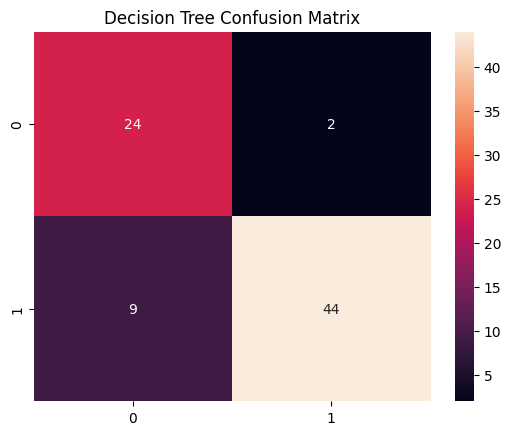


Random Forest Results
Accuracy: 0.8860759493670886
Precision: 0.9782608695652174
Recall: 0.8490566037735849
F1 Score: 0.9090909090909091


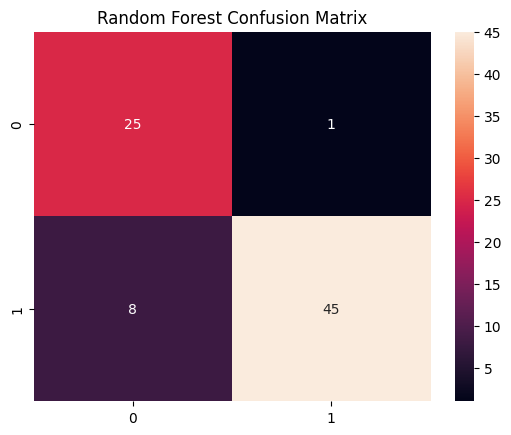


Logistic Regression Results
Accuracy: 0.8987341772151899
Precision: 0.9787234042553191
Recall: 0.8679245283018868
F1 Score: 0.92


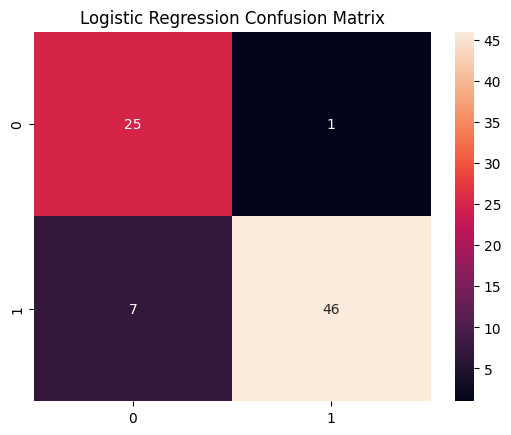

In [ ]:
evaluate_model("Decision Tree", best_dt, X_test, y_test)
evaluate_model("Random Forest", best_rf, X_test, y_test)
evaluate_model("Logistic Regression", best_lr, X_test_scaled, y_test)

Text(0.5, 1.0, 'Decision Tree Visualization (Top Decision Branches)')

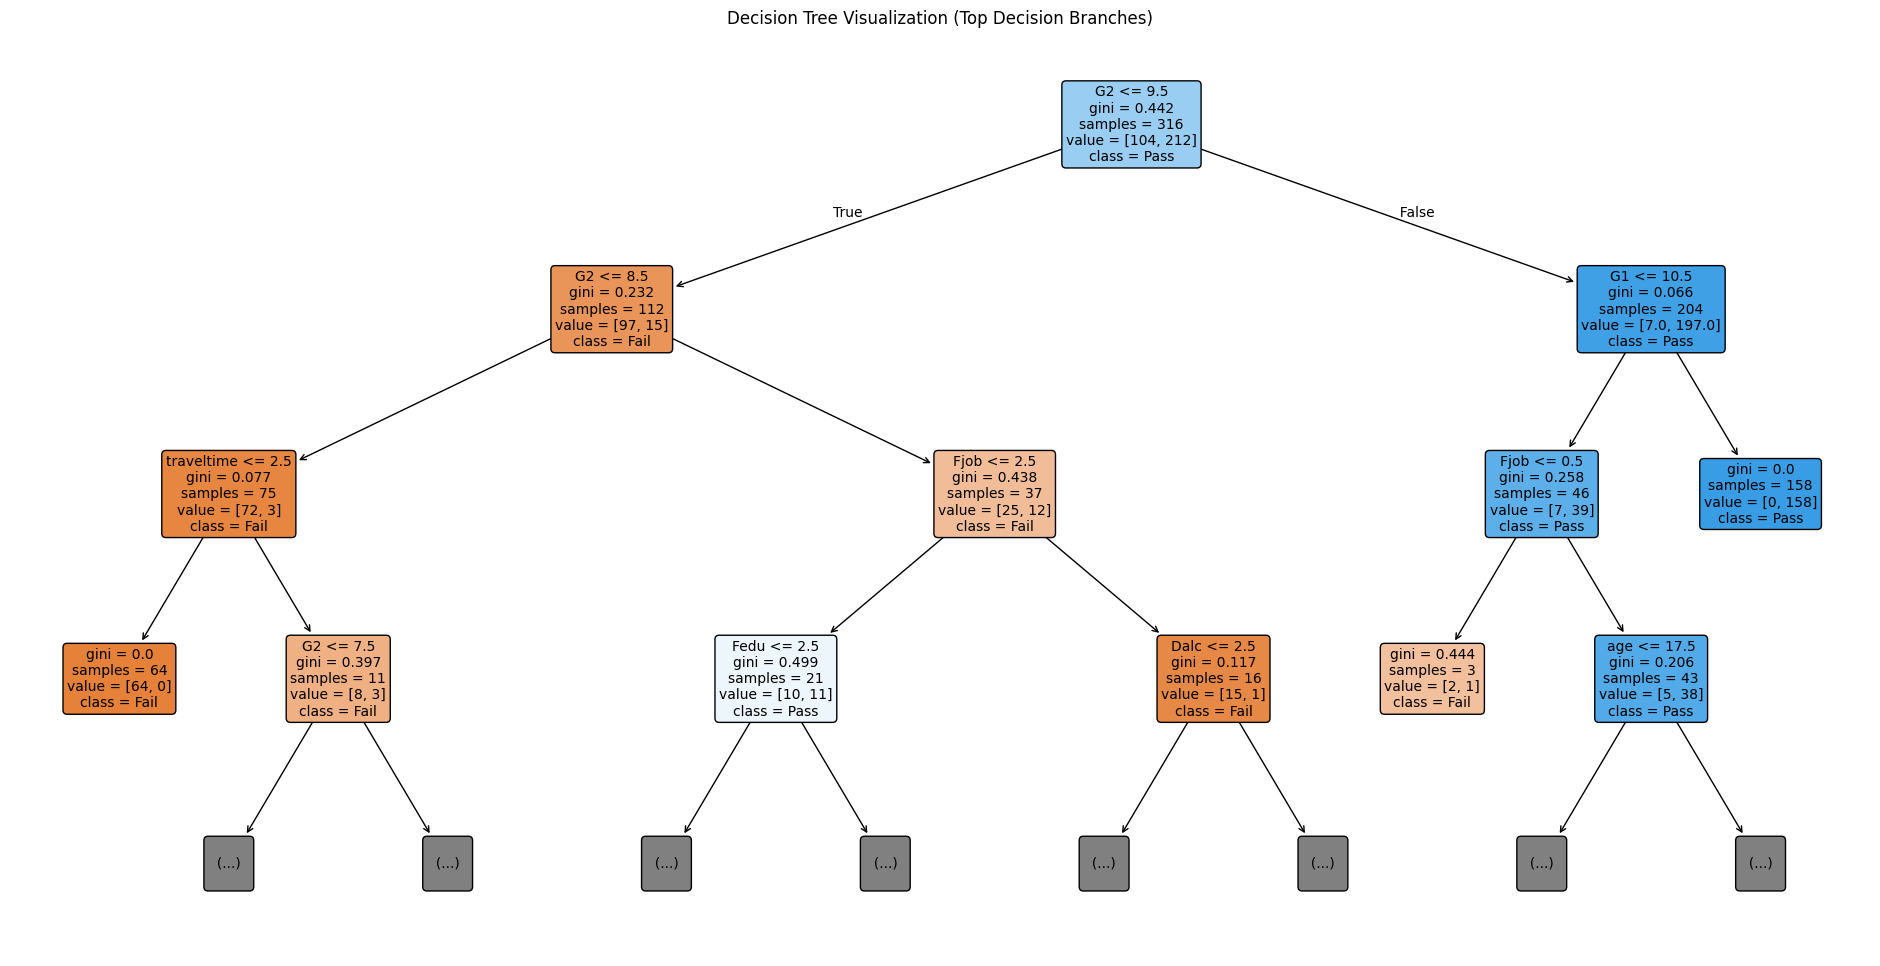

In [ ]:

# Decision Tree Visualization




plt.figure(figsize=(24,12))

plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.title("Decision Tree Visualization (Top Decision Branches)")


In [ ]:
print(X_train.columns)

Index(['age', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian',
       'traveltime', 'studytime', 'failures', 'schoolsup', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='object')


### ROC + AUC

In [ ]:
'''def plot_roc(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=name)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    print(name, "AUC:", roc_auc_score(y_test, y_prob))'''

'def plot_roc(model, X_test, y_test, name):\n    y_prob = model.predict_proba(X_test)[:,1]\n\n    fpr, tpr, _ = roc_curve(y_test, y_prob)\n\n    plt.plot(fpr, tpr, label=name)\n    plt.xlabel("False Positive Rate")\n    plt.ylabel("True Positive Rate")\n    plt.title("ROC Curve")\n    plt.legend()\n    plt.show()\n\n    print(name, "AUC:", roc_auc_score(y_test, y_prob))'

In [ ]:
def plot_roc(model, X_test, y_test, name):

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc_score = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(6,5))

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"{name} ROC Curve")

    plt.legend(loc="lower right")

    plt.show()

    print(name, "AUC:", auc_score)

Calling Functions

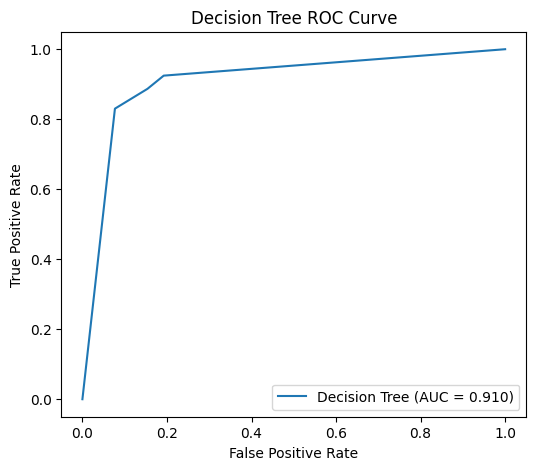

Decision Tree AUC: 0.9100145137880988


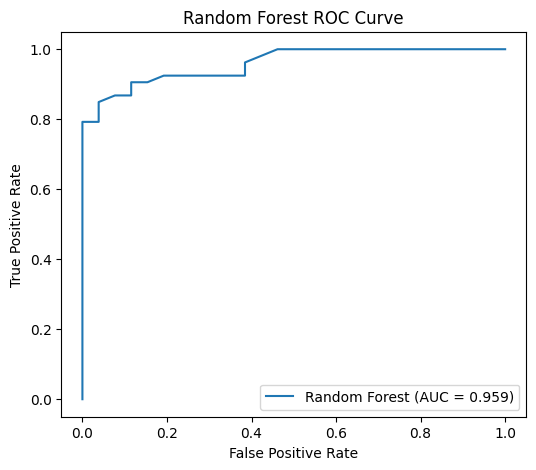

Random Forest AUC: 0.9586357039187229


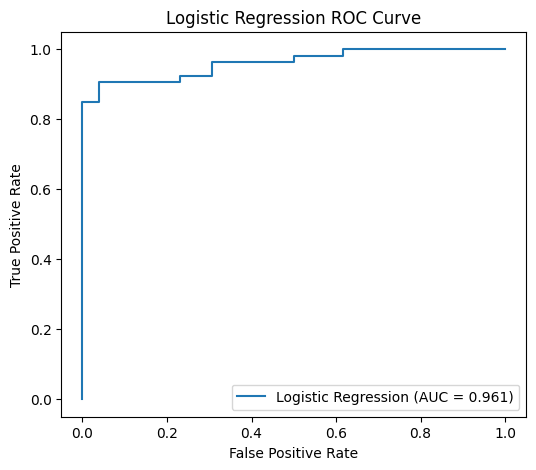

Logistic Regression AUC: 0.9608127721335269


In [ ]:
plot_roc(best_dt, X_test, y_test, "Decision Tree")
plot_roc(best_rf, X_test, y_test, "Random Forest")
plot_roc(best_lr, X_test_scaled, y_test, "Logistic Regression")

Combined ROC Curve

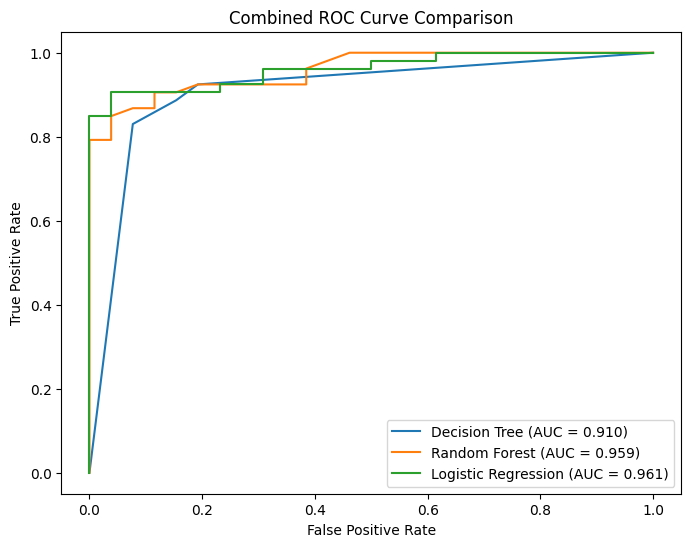

In [ ]:

plt.figure(figsize=(8,6))

# Decision Tree
y_prob_dt = best_dt.predict_proba(X_test)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {auc_dt:.3f})"
)

# Random Forest
y_prob_rf = best_rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

# Logistic Regression
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Combined ROC Curve Comparison")

plt.legend(loc="lower right")

plt.show()

Dataset Summary

In [ ]:
print("Dataset shape after preprocessing:", df_encoded.shape)
print("Dataset shape after feature reduction:", X_reduced.shape)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Dataset shape after preprocessing: (395, 34)
Dataset shape after feature reduction: (395, 20)
Training set size: (316, 20)
Test set size: (79, 20)


Class Distribution

In [ ]:
print("\nClass distribution (full dataset):")
print(y.value_counts(normalize=True))

print("\nTraining set distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set distribution:")
print(y_test.value_counts(normalize=True))


Class distribution (full dataset):
G3_pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64

Training set distribution:
G3_pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64

Test set distribution:
G3_pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64


Combine ROC curve

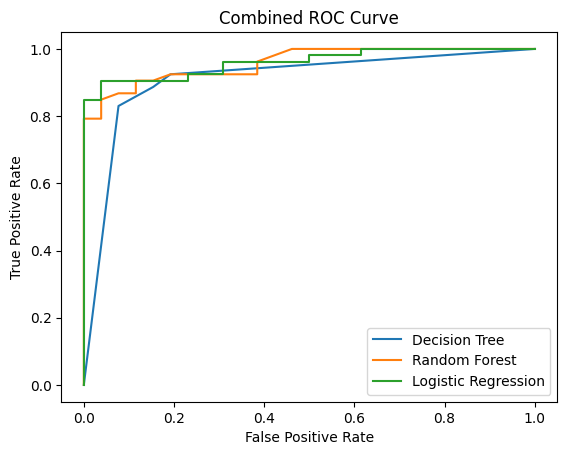

In [ ]:
plt.figure()

# Decision Tree
y_prob_dt = best_dt.predict_proba(X_test)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")

# Random Forest
y_prob_rf = best_rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

# Logistic Regression
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curve")
plt.legend()
plt.show()

Model Comparison Table

In [ ]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, best_dt.predict(X_test)),
        accuracy_score(y_test, best_rf.predict(X_test)),
        accuracy_score(y_test, best_lr.predict(X_test_scaled))
    ],
    'Precision': [
        precision_score(y_test, best_dt.predict(X_test)),
        precision_score(y_test, best_rf.predict(X_test)),
        precision_score(y_test, best_lr.predict(X_test_scaled))
    ],
    'Recall': [
        recall_score(y_test, best_dt.predict(X_test)),
        recall_score(y_test, best_rf.predict(X_test)),
        recall_score(y_test, best_lr.predict(X_test_scaled))
    ],
    'F1-score': [
        f1_score(y_test, best_dt.predict(X_test)),
        f1_score(y_test, best_rf.predict(X_test)),
        f1_score(y_test, best_lr.predict(X_test_scaled))
    ],
    'AUC': [
        roc_auc_score(y_test, best_dt.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:,1])
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-score       AUC
0        Decision Tree  0.860759   0.956522  0.830189  0.888889  0.910015
1        Random Forest  0.886076   0.978261  0.849057  0.909091  0.958636
2  Logistic Regression  0.898734   0.978723  0.867925  0.920000  0.960813
